In [45]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

# Comenzamos con el mismo código de la clase pasada:

El problema comienza con dos cuerpos que se atraen gravitacionalmente:

In [46]:
# Unidades canónicas
G = 1.0 

m1 = 1.0
r1_vec_0 = np.array([0.0, 0.0, 0.0])
v1_vec_0 = np.array([0.0, 0.0, 0.0])

m2 = 1.0
r2_vec_0 = np.array([1.0, 0.0, 0.0])
v2_vec_0 = np.array([0.5, 1.0, 0.0])

M = m1 + m2

La pregunta que se hace la persona es: ¿Cuál es la trayectoria que siguen las dos partículas con esas condiciones iniciales? 

El que tiene solución es el problema relativo:

In [47]:
mu = G * (m1 + m2)
r_vec_0 = r1_vec_0 - r2_vec_0
v_vec_0 = v1_vec_0 - v2_vec_0

r0 = np.linalg.norm(r_vec_0) 
v0 = np.linalg.norm(v_vec_0)

Calculemos las cuadraturas del problema (constantes)

In [48]:
h_vec = np.cross(r_vec_0, v_vec_0)
#%timeit h = np.linalg.norm(h_vec)
#%timeit h = np.sqrt(h_vec @ h_vec)
h = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2) #Mejor opcion
#%timeit h = (h_vec @ h_vec)**0.5

In [49]:
h_vec, h

(array([0., 0., 1.]), np.float64(1.0))

In [50]:
e_vec = np.cross(v_vec_0, h_vec) / mu - r_vec_0 / r0
e = (e_vec @ e_vec)**0.5

In [51]:
e_vec, e 
#Esto indica que la órbita es elíptica, ya que el excentricidad es menor a 1.
#Y apunta al punto de mínima distancia. 

(array([0.5 , 0.25, 0.  ]), np.float64(0.5590169943749475))

In [52]:
epsilon = v0**2 / 2 - mu / r0
epsilon
#El signo negativo indica que la órbita es cerrada, es decir, 
#el cuerpo está ligado al otro.

np.float64(-1.375)

Verifiquemos la formula de e:

In [53]:
e = (1 + 2*epsilon*h**2 / mu**2)**0.5
e

np.float64(0.5590169943749475)

Cantidades geométricas derivadas:

In [54]:
p = h**2 / mu
q = p / (1 + e)
Q = p / (1 - e)
p, q, Q


(np.float64(0.5),
 np.float64(0.3207149131818564),
 np.float64(1.1338305413635983))

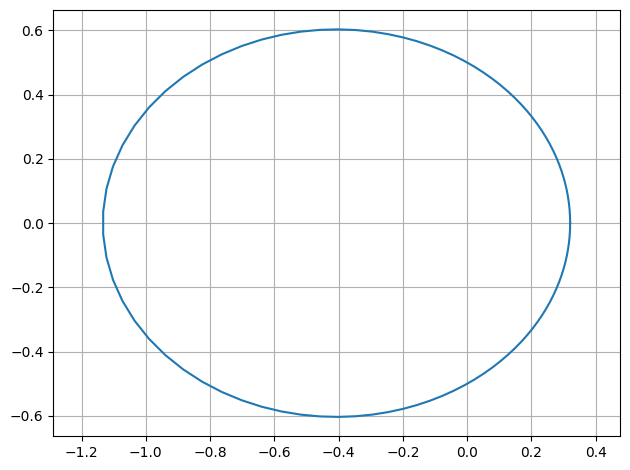

In [55]:
thetars = np.linspace(0, 2 * np.pi, 100)

rs = p / (1 + e * np.cos(thetars))

xfs = rs * np.cos(thetars)
yfs = rs * np.sin(thetars)

plt.plot(xfs, yfs)
plt.axis('equal')
plt.grid()
plt.tight_layout()

In [56]:
rvecs = np.array([xfs, yfs]).T

rlvecs = m2 / M * rvecs
r2vecs = -m1 / M * rvecs

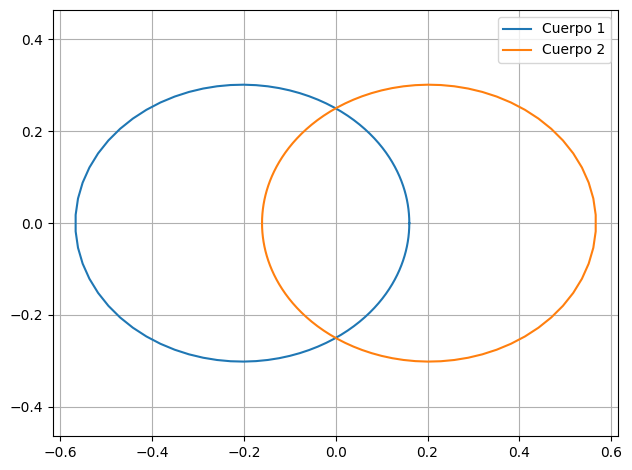

In [57]:
plt.plot(rlvecs[:,0], rlvecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')
plt.legend()
plt.axis('equal')
plt.grid()
plt.tight_layout()

In [58]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]
ts = np.linspace(0, 10, 300)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

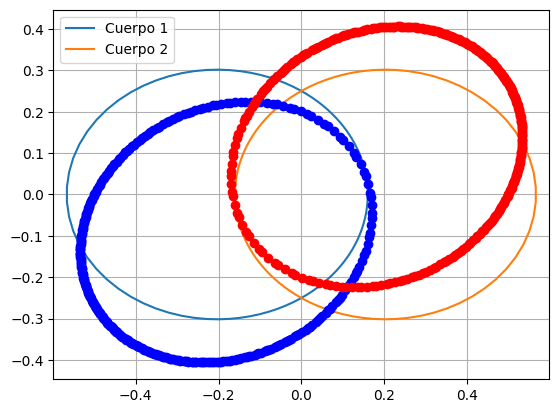

In [59]:
plt.plot(rlvecs[:,0], rlvecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')

plt.plot(rps[0,:,0], rps[0,:,1], 'bo')
plt.plot(rps[1,:,0], rps[1,:,1], 'ro')

plt.legend()
plt.axis('equal')
plt.grid()


## De elementos orbitales a la órbita en el espacio

In [60]:
import spiceypy as spy

In [61]:
deg = np.pi / 180.0

In [62]:
e =	0.1911663355386932*deg
a = 0.9223803173917017*deg
q = 0.7460522521429133*deg
i = 3.340958441017069*deg 
node = 203.8996515621043*deg
peri = 126.6728325163065*deg

Matriz de rotación:

In [63]:
Rz_omega = spy.rotate(peri, 3)
Rx_i =  spy.rotate(i, 1)
Rz_Omega = spy.rotate(node, 3)

M_astro2perifocal = Rz_omega @ Rx_i @ Rz_Omega
M_astro2perifocal

array([[ 0.87042569, -0.4900758 ,  0.04674214],
       [ 0.49173333,  0.87004992, -0.03480605],
       [-0.02361039,  0.05328075,  0.99830041]])

In [64]:
Rz__menos_omega = spy.rotate(-peri,3)
Rx__menos_i =  spy.rotate(-i,1)
Rz__menos_Omega = spy.rotate(-node,3)

M_perifocal2astro = Rz_Omega @ Rx_i @ Rz_omega
M_perifocal2astro

array([[ 0.87042569, -0.49173333, -0.02361039],
       [ 0.4900758 ,  0.87004992, -0.05328075],
       [ 0.04674214,  0.03480605,  0.99830041]])

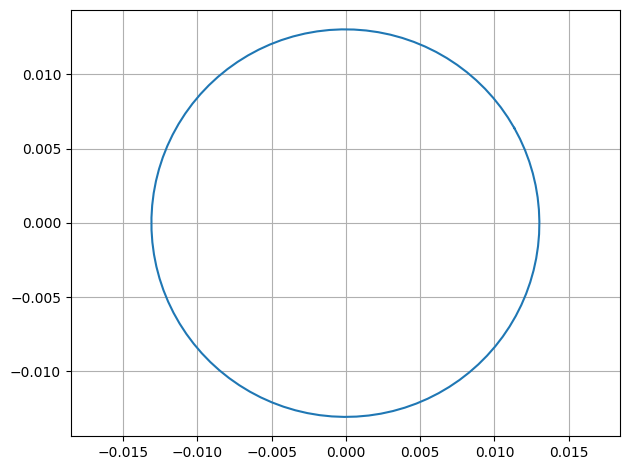

In [67]:
fs = np.linspace(0, 2*np.pi, 100)
p = q * (1 + e)
rs = p / (1 + e*np.cos(fs))

xfs = rs * np.cos(fs)
yfs = rs * np.sin(fs)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()
